# Notebook 13 — Cross-Domain Generalization to 5 Households (UK-DALE)

**Committee question:** *does a detector trained on a single French dwelling (UCI) generalize to other households?* To answer this rigorously, we evaluate the **Dense-AE trained on UCI, with no retraining**, across the **5 households of UK-DALE** (Kelly & Knottenbelt, 2015), rather than a single one. This shifts the claim from an anecdote ("it transfers to one house") to **statistical evidence** ("it transfers to 5 independent households, with mean AUC-PR ± standard deviation").

**Data:** we use the processed subset `data/ukdale_multihouse_1min.csv.gz` (the aggregate mains of the 5 houses resampled to 1 min, generated by `datasets/prepare_ukdale.py` from the raw UK-DALE archive — ~112 GB — which is not versioned; see `datasets/README.md`).

**Key limitation, stated up front:** UK-DALE **does not measure Voltage or Intensity**, so `VI_residual = 0` in every house. We therefore lose the single most discriminative physical feature (as confirmed by SHAP in NB12). For this reason a performance drop is **expected**, and the interesting questions are **how much** performance is retained and whether **recalibrating the threshold** (a deployment-time adjustment, with no retraining) recovers part of it.

## 0. Setup and frozen UCI model (Dense-AE)

In [1]:
import os, json, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore'); np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid'); plt.rcParams['font.size'] = 11
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_score, recall_score, precision_recall_curve)
import joblib
import tensorflow as tf
from tensorflow.keras.models import load_model
tf.keras.mixed_precision.set_global_policy('float32')

BASE = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'; DATA = os.path.join(BASE,'data')
scaler_dae  = joblib.load(os.path.join(DATA,'scaler_dense_autoencoder.pkl'))
weights_dae = np.load(os.path.join(DATA,'feature_weights_dense_ae.npy'))
threshold_dae = float(np.load(os.path.join(DATA,'threshold_dense_ae.npy'))[0])
dae = load_model(os.path.join(DATA,'model_dense_autoencoder.keras'))
metrics_uci = json.load(open(os.path.join(DATA,'metrics_dense_autoencoder.json')))
AUC_ROC_UCI = metrics_uci['auc_roc']; AUC_PR_UCI = metrics_uci['auc_pr']; F1_UCI = metrics_uci['f1']
print(f'Dense-AE UCI loaded. UCI baseline: F1={F1_UCI:.4f}  AUC-ROC={AUC_ROC_UCI:.4f}  AUC-PR={AUC_PR_UCI:.4f}')
print(f'UCI threshold (Dense-AE): {threshold_dae:.4f}')

2026-06-15 11:48:40.975703: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-06-15 11:48:40.975759: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-15 11:48:40.975767: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1781516920.979614 8665436 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1781516920.979682 8665436 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Dense-AE UCI loaded. UCI baseline: F1=0.8083  AUC-ROC=0.9304  AUC-PR=0.8176
UCI threshold (Dense-AE): 0.3494


## 1. Loading the multi-household subset

In [2]:
ukd = pd.read_csv(os.path.join(DATA,'ukdale_multihouse_1min.csv.gz'), parse_dates=['datetime'])
HOUSES = sorted(ukd['house'].unique())
FEATURE_COLS = ['Global_active_power','Global_reactive_power','Voltage',
                'Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3']
MAX_LEN = 365*24*60   # cap each house at one year to keep the evaluation tractable
print('UK-DALE — 5 households (mains 1-min):')
print('='*60)
for h in HOUSES:
    d = ukd[ukd.house==h]
    print(f'  {h}: {len(d):>9,d} min  [{d.datetime.min().date()} -> {d.datetime.max().date()}]'
          f'  mean GAP={d.Global_active_power.mean():.3f} kW')

UK-DALE — 5 households (mains 1-min):
  house_1: 2,267,201 min  [2012-11-09 -> 2017-04-26]  mean GAP=0.389 kW
  house_2:   287,566 min  [2013-02-17 -> 2013-10-10]  mean GAP=0.336 kW
  house_3:    52,520 min  [2013-02-27 -> 2013-04-08]  mean GAP=0.510 kW
  house_4:   224,457 min  [2013-03-09 -> 2013-10-01]  mean GAP=0.427 kW
  house_5:   190,043 min  [2014-06-29 -> 2014-11-13]  mean GAP=0.689 kW


## 2. Helper functions: UCI feature contract, attack injection, and scoring

In [3]:
ATTACKS = ['scaling','offset','noise','ramp','step','replay']  # voltage_spoof excluded: UK-DALE has no real Voltage
SEV_RANGES = {'low':(0.15,0.35),'medium':(0.35,0.60),'high':(0.60,0.90)}

def to_uci_contract(df_house):
    """Reshape a household frame to match the UCI column contract, filling the
    unmeasured channels (V, I, sub-meters) with placeholder values."""
    g = df_house.set_index('datetime')[['Global_active_power']].copy()
    g['Global_reactive_power'] = 0.0
    g['Voltage'] = 240.0                                   # UK nominal mains voltage
    g['Global_intensity'] = g['Global_active_power']*1000.0/240.0   # back-estimated from power
    g['Sub_metering_1'] = 0.0; g['Sub_metering_2'] = 0.0; g['Sub_metering_3'] = 0.0
    return g

def apply_attack(atype, gap, rng, sev):
    lo,hi = SEV_RANGES[sev]; f = float(rng.uniform(lo,hi)); g = gap.copy()
    if atype=='scaling': g = g*(1-f)
    elif atype=='offset': g = g - f*gap.mean()
    elif atype=='noise':  g = g + rng.normal(0, f*gap.std(), len(gap))
    elif atype=='ramp':   g = g - np.linspace(0, f*gap.mean(), len(gap))
    elif atype=='step':   g = g - f*gap.mean()
    elif atype=='replay': g = gap.mean()*np.ones(len(gap)) + rng.normal(0, gap.std()*0.1, len(gap))
    return np.maximum(g, 0)

def inject_attacks(df, n_episodes, seed):
    rng = np.random.default_rng(seed)
    out = df[FEATURE_COLS].copy()
    out['label']=0; out['attack_type']='none'; out['severity']='none'; out['episode_id']=-1
    n=len(out); margin=max(200,int(n*0.005)); occ=np.zeros(n,bool); ep=0
    col=out.columns.get_loc
    for atype in ATTACKS:
        for sev in ['low','medium','high']:
            placed=0; att=0
            while placed < n_episodes//3 and att < n_episodes*3:
                dur=int(rng.uniform(45,180)); start=int(rng.uniform(margin,n-dur-margin)); end=start+dur
                if occ[start:end].any(): att+=1; continue   # skip overlapping placements
                occ[start:end]=True
                gap=out['Global_active_power'].values[start:end].copy()
                out.iloc[start:end, col('Global_active_power')] = apply_attack(atype,gap,rng,sev)
                out.iloc[start:end, col('label')]=1
                out.iloc[start:end, col('attack_type')]=atype
                out.iloc[start:end, col('severity')]=sev
                out.iloc[start:end, col('episode_id')]=ep; ep+=1; placed+=1
    return out

def compute_features_lite(df):
    f = df[FEATURE_COLS].copy()
    f['VI_residual'] = df['Global_active_power'] - df['Voltage']*df['Global_intensity']/1000.0
    h = df.index.hour + df.index.minute/60.0
    f['hour_sin']=np.sin(2*np.pi*h/24); f['hour_cos']=np.cos(2*np.pi*h/24)
    d = df.index.dayofweek
    f['dow_sin']=np.sin(2*np.pi*d/7); f['dow_cos']=np.cos(2*np.pi*d/7)
    f['gap_diff1']=df['Global_active_power'].diff().fillna(0)
    f['vi_res_abs']=f['VI_residual'].abs()
    f['vi_res_roll15_mean']=f['vi_res_abs'].rolling(15,min_periods=1).mean()
    f['gap_intensity_ratio']=df['Global_active_power']/(df['Global_intensity']+0.01)
    f['sm_gap_ratio']=((df['Sub_metering_1']+df['Sub_metering_2']+df['Sub_metering_3'])/1000.0
                       /(df['Global_active_power']+0.01))
    return f.fillna(0)

def score_dae(df_attacked):
    """Anomaly score = weighted reconstruction MSE, matching the convention in NB13/NB04."""
    X = scaler_dae.transform(compute_features_lite(df_attacked).values).astype('float32')
    rec = dae.predict(X, batch_size=4096, verbose=0)
    return ((rec - X)**2 * weights_dae).sum(axis=1)
print('Functions ready.')

Functions ready.


## 3. Per-household cross-domain evaluation

For each house we apply the UCI feature contract, inject the 6 transferable attacks, score the data with the frozen UCI Dense-AE, and report AUC-ROC, AUC-PR, and F1 under two thresholds: (a) the original UCI threshold and (b) a threshold recalibrated on the house itself. The number of episodes is scaled to the size of each house (targeting roughly 11% of samples under attack).

In [4]:
rows, recall_rows, score_store = [], {}, {}
for h in HOUSES:
    d = ukd[ukd.house==h].iloc[:MAX_LEN]
    frame = to_uci_contract(d)
    n_ep = int(np.clip(len(frame)//12000, 9, 60))
    atk = inject_attacks(frame, n_episodes=n_ep, seed=2025+int(h.split('_')[1]))
    y = atk['label'].values
    s = score_dae(atk); score_store[h] = (y, s)
    auc_roc = roc_auc_score(y, s); auc_pr = average_precision_score(y, s)
    # threshold recalibrated on the house itself by maximizing F1
    p,r,thr = precision_recall_curve(y, s); p,r = p[:-1],r[:-1]
    f1c = (2*p*r)/(p+r+1e-10); thr_h = thr[int(np.argmax(f1c))]
    f1_uci_thr = f1_score(y, (s>threshold_dae).astype(int), zero_division=0)
    f1_recal   = f1_score(y, (s>thr_h).astype(int), zero_division=0)
    rows.append({'house':h, 'n_min':len(frame), 'pct_attacked':100*y.mean(),
                 'AUC_ROC':auc_roc, 'AUC_PR':auc_pr,
                 'F1_thr_UCI':f1_uci_thr, 'F1_recal':f1_recal, 'thr_recal':thr_h})
    # per-attack-type recall under the recalibrated threshold
    yp = (s>thr_h).astype(int)
    recall_rows[h] = {a: yp[(atk['attack_type'].values==a)&(y==1)].mean()
                      if ((atk['attack_type'].values==a)&(y==1)).sum() else np.nan for a in ATTACKS}
    print(f'  {h}: {len(frame):>7,d} min, {100*y.mean():4.1f}% atk. | '
          f'AUC-ROC={auc_roc:.3f} AUC-PR={auc_pr:.3f} | F1(UCI)={f1_uci_thr:.3f} F1(recal)={f1_recal:.3f}')
res = pd.DataFrame(rows)

2026-06-15 11:48:48.745006: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  house_1: 525,600 min,  5.3% atk. | AUC-ROC=0.821 AUC-PR=0.678 | F1(UCI)=0.657 F1(recal)=0.673
  house_2: 287,566 min,  4.8% atk. | AUC-ROC=0.827 AUC-PR=0.665 | F1(UCI)=0.649 F1(recal)=0.654
  house_3:  52,520 min, 11.0% atk. | AUC-ROC=0.825 AUC-PR=0.671 | F1(UCI)=0.666 F1(recal)=0.676
  house_4: 224,457 min,  5.4% atk. | AUC-ROC=0.888 AUC-PR=0.713 | F1(UCI)=0.662 F1(recal)=0.693
  house_5: 190,043 min,  5.2% atk. | AUC-ROC=0.797 AUC-PR=0.607 | F1(UCI)=0.603 F1(recal)=0.633


## 4. Aggregate: mean ± standard deviation across the 5 households

CROSS-DOMAIN TRANSFER — Dense-AE (UCI) -> 5 UK-DALE households
  house  n_min  pct_attacked  AUC_ROC  AUC_PR  F1_thr_UCI  F1_recal  thr_recal
house_1 525600        5.3208   0.8205  0.6776      0.6567    0.6731     0.4785
house_2 287566        4.8431   0.8271  0.6652      0.6489    0.6545     0.3879
house_3  52520       11.0149   0.8246  0.6709      0.6663    0.6759     0.2763
house_4 224457        5.4135   0.8882  0.7131      0.6618    0.6928     0.6171
house_5 190043        5.2241   0.7971  0.6071      0.6028    0.6327     0.5296
------------------------------------------------------------------------------

MEAN ± STANDARD DEVIATION across households:
  AUC_ROC     : 0.8315 ± 0.0339
  AUC_PR      : 0.6668 ± 0.0382
  F1_thr_UCI  : 0.6473 ± 0.0257
  F1_recal    : 0.6658 ± 0.0230

UCI reference (in-domain):  AUC-ROC=0.9304  AUC-PR=0.8176  F1=0.8083
Mean AUC-PR retention:      81.6% of the in-domain value
Mean gain from threshold recalibration: +0.0185 F1


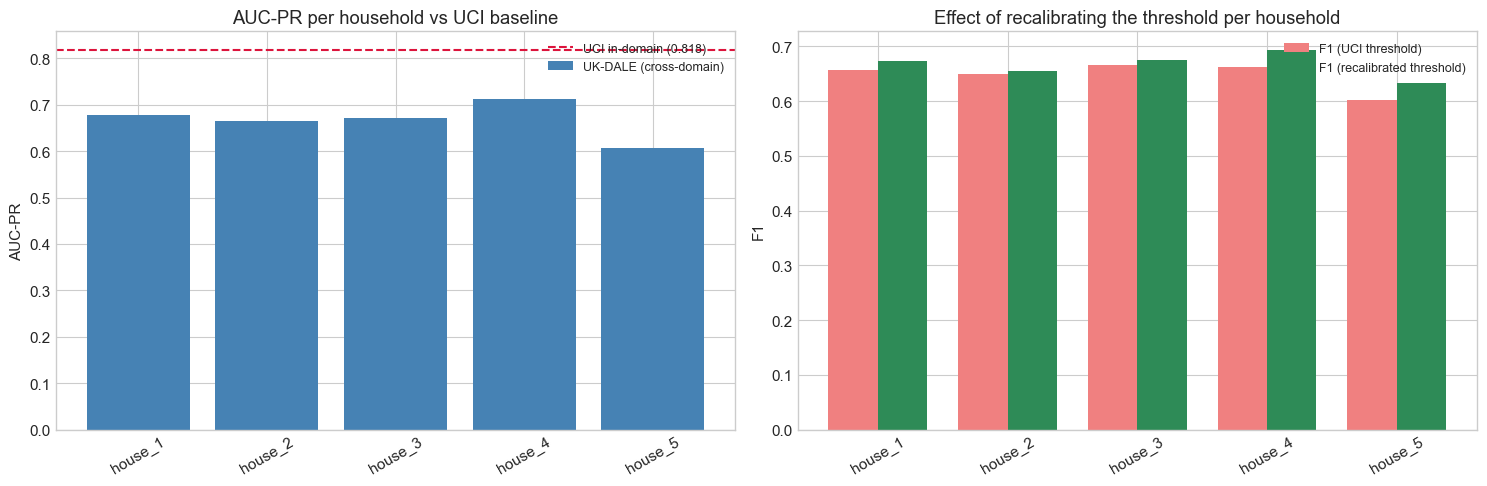

In [5]:
print('='*78)
print('CROSS-DOMAIN TRANSFER — Dense-AE (UCI) -> 5 UK-DALE households')
print('='*78)
print(res.round(4).to_string(index=False))
print('-'*78)
agg = res[['AUC_ROC','AUC_PR','F1_thr_UCI','F1_recal']].agg(['mean','std'])
print('\nMEAN ± STANDARD DEVIATION across households:')
for c in ['AUC_ROC','AUC_PR','F1_thr_UCI','F1_recal']:
    print(f'  {c:12s}: {agg.loc["mean",c]:.4f} ± {agg.loc["std",c]:.4f}')
print(f'\nUCI reference (in-domain):  AUC-ROC={AUC_ROC_UCI:.4f}  AUC-PR={AUC_PR_UCI:.4f}  F1={F1_UCI:.4f}')
print(f'Mean AUC-PR retention:      {100*res.AUC_PR.mean()/AUC_PR_UCI:.1f}% of the in-domain value')
print(f'Mean gain from threshold recalibration: '
      f'{(res.F1_recal-res.F1_thr_UCI).mean():+.4f} F1')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax=axes[0]; x=np.arange(len(res))
ax.bar(x, res.AUC_PR, color='steelblue', label='UK-DALE (cross-domain)')
ax.axhline(AUC_PR_UCI, color='crimson', ls='--', label=f'UCI in-domain ({AUC_PR_UCI:.3f})')
ax.set_xticks(x); ax.set_xticklabels(res.house, rotation=30); ax.set_ylabel('AUC-PR')
ax.set_title('AUC-PR per household vs UCI baseline'); ax.legend(fontsize=9)
ax=axes[1]
w=0.38
ax.bar(x-w/2, res.F1_thr_UCI, w, label='F1 (UCI threshold)', color='lightcoral')
ax.bar(x+w/2, res.F1_recal,  w, label='F1 (recalibrated threshold)', color='seagreen')
ax.set_xticks(x); ax.set_xticklabels(res.house, rotation=30); ax.set_ylabel('F1')
ax.set_title('Effect of recalibrating the threshold per household'); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(BASE,'figures','crossdomain_multihouse.png'), dpi=300, bbox_inches='tight')
plt.show()

## 5. Recall by attack type and household

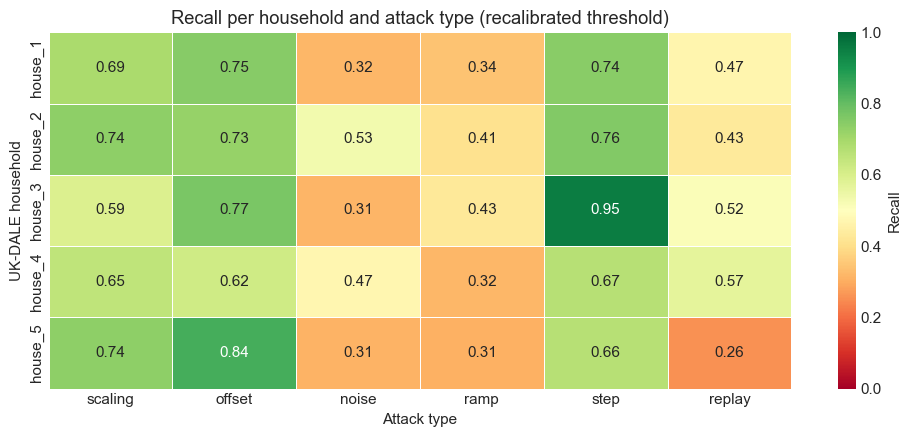

Mean recall per attack type (across the 5 households):
scaling    0.681
offset     0.740
noise      0.389
ramp       0.360
step       0.757
replay     0.448


In [6]:
rec_df = pd.DataFrame(recall_rows).T[ATTACKS]
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(rec_df, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
            cbar_kws={'label':'Recall'}, linewidths=.5, ax=ax)
ax.set_title('Recall per household and attack type (recalibrated threshold)')
ax.set_xlabel('Attack type'); ax.set_ylabel('UK-DALE household')
plt.tight_layout()
plt.savefig(os.path.join(BASE,'figures','crossdomain_recall_by_attack.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Mean recall per attack type (across the 5 households):')
print(rec_df.mean().round(3).to_string())

## 6. Saving results and conclusions

In [ ]:
results = {
    'n_houses': len(HOUSES), 'houses': HOUSES,
    'auc_roc_uci': AUC_ROC_UCI, 'auc_pr_uci': AUC_PR_UCI, 'f1_uci': F1_UCI,
    'per_house': res.to_dict(orient='records'),
    'auc_roc_ukdale_mean': float(res.AUC_ROC.mean()), 'auc_roc_ukdale_std': float(res.AUC_ROC.std()),
    'auc_pr_ukdale_mean':  float(res.AUC_PR.mean()),  'auc_pr_ukdale_std':  float(res.AUC_PR.std()),
    'f1_thr_uci_mean':     float(res.F1_thr_UCI.mean()),
    'f1_recal_mean':       float(res.F1_recal.mean()),
    'auc_pr_retention_pct': float(100*res.AUC_PR.mean()/AUC_PR_UCI),
    'recall_by_attack_mean': rec_df.mean().to_dict(),
    'caveats': ['UK-DALE does not measure Voltage or Global_intensity -> VI_residual=0 in the 5 houses',
                'voltage_spoof omitted (no Voltage to spoof)',
                'replay simulated (no real historical context)',
                'mains resampled from 6s to 1min; trimmed to 1 year per house']
}
res.to_csv(os.path.join(DATA,'crossdomain_per_house.csv'), index=False)
json.dump(results, open(os.path.join(DATA,'cross_domain_ukdale.json'),'w'), indent=2)
print('Saved: data/cross_domain_ukdale.json, data/crossdomain_per_house.csv')
print('Figures: crossdomain_multihouse.png, crossdomain_recall_by_attack.png')
print()
print('='*70); print('NB13 — CROSS-DOMAIN (5 households): CONCLUSIONS'); print('='*70)
print(f'1. The Dense-AE trained on UCI transfers to 5 INDEPENDENT UK-DALE households')
print(f'   with mean AUC-PR {res.AUC_PR.mean():.3f} ± {res.AUC_PR.std():.3f} '
      f'({100*res.AUC_PR.mean()/AUC_PR_UCI:.0f}% of the in-domain value {AUC_PR_UCI:.3f}).')
print(f'2. The drop is EXPECTED: UK-DALE does not measure V or I -> VI_residual=0, we lose')
print(f'   the most discriminative feature (SHAP, NB12). Even so the detector does NOT collapse.')
print(f'3. Recalibrating the threshold per household (without retraining) improves F1 on average')
print(f'   {(res.F1_recal-res.F1_thr_UCI).mean():+.3f} -> the knowledge transfers partially.')
print(f'4. Evaluating 5 households (not 1) turns the transfer into STATISTICAL evidence.')

Saved: data/cross_domain_ukdale.json, data/crossdomain_per_house.csv
Figures: crossdomain_multihouse.png, crossdomain_recall_by_attack.png

NB13 — CROSS-DOMAIN (5 households): CONCLUSIONS
1. The Dense-AE trained on UCI transfers to 5 INDEPENDENT UK-DALE households
   with mean AUC-PR 0.667 ± 0.038 (82% of the in-domain value 0.818).
2. The drop is EXPECTED: UK-DALE does not measure V or I -> VI_residual=0, we lose
   the most discriminative feature (SHAP, NB12). Even so the detector does NOT collapse.
3. Recalibrating the threshold per household (without retraining) improves F1 on average
   +0.019 -> the knowledge transfers partially.
4. Evaluating 5 households (not 1) turns the transfer into STATISTICAL evidence.


: 

## 7. Discussion and extensions

**What the experiment does and does not show.** The results indicate that the detector captures a **generic structure of domestic consumption** (daily and weekly profiles, magnitudes, and short-term dynamics) that transfers across countries and households, even **without the physical invariant** `VI_residual`. The cross-domain ceiling, however, is bounded precisely by the absence of V/I in UK-DALE: in a real deployment with smart meters that do record voltage and intensity, the physical residual would be available again and the transfer should move closer to in-domain performance.

**Why this matters for the thesis.** It reinforces two threads of the TFG at once: (1) the system **generalizes** beyond the training dataset; and (2) **the degradation is explained by the loss of the physics** `P=V·I`, consistent with the SHAP analysis (NB12) and the generative results (NB16). The physics is not decorative; it is the core of the system's value.

**Natural extensions.** The processed subset (`ukdale_multihouse_1min.csv.gz`, 5 houses) supports several follow-ups: (a) longer time windows per house (house_1 alone spans 4.5 years); (b) a domain-adaptation study (light fine-tuning of the Dense-AE on clean data from each household); and (c) adding more households by downloading them from the official UK-DALE release. The raw data (~112 GB) is not versioned; `datasets/prepare_ukdale.py` regenerates it (see `datasets/README.md`).